In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import matplotlib.gridspec as gridspec

In [2]:
df = pd.read_csv('../data/raw/predictive-maintenance-dataset.csv')

In [3]:
rows,columns = df.shape
print('dataset has rows ', rows)
print('dataset has total columns ',columns)

dataset has rows  112001
dataset has total columns  9


In [4]:
df.head()

,ID,revolutions,humidity,vibration,x1,x2,x3,x4,x5
0,1,93.744,73.999,18.0,167.743,19.745,1.266828,8787.937536,5475.852001
1,2,93.740,73.999,18.0,167.739,19.741,1.266774,8787.187600,5475.852001
2,3,93.736,73.998,18.0,167.734,19.738,1.266737,8786.437696,5475.704004
3,4,93.732,73.998,18.0,167.730,19.734,1.266683,8785.687824,5475.704004
4,5,93.729,73.998,18.0,167.727,19.731,1.266642,8785.125441,5475.704004


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 112001 entries, 0 to 112000
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   ID           112001 non-null  int64  
 1   revolutions  112001 non-null  float64
 2   humidity     112001 non-null  float64
 3   vibration    109563 non-null  float64
 4   x1           112001 non-null  float64
 5   x2           112001 non-null  float64
 6   x3           112001 non-null  float64
 7   x4           112001 non-null  float64
 8   x5           112001 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 7.7 MB


In [6]:
#we will check for missing values in each column
df.isnull().sum()

ID                0
revolutions       0
humidity          0
vibration      2438
x1                0
x2                0
x3                0
x4                0
x5                0
dtype: int64

In [7]:
# total percentage of null values for vibration (target feature)
missingValuePercentage = (df.isnull().sum()['vibration'] / len(df)) * 100
print('Missing value percentage for vibrations is ', missingValuePercentage)

Missing value percentage for vibrations is  2.1767662788725097


In [8]:
# The dataset description says: sampled at 4 Hz
# 4 Hz means 4 readings per second = 1 reading every 0.25 seconds time = 1/frequency 
total_seconds = rows / 4
total_hours   = total_seconds / 3600
print("TIME DURATION OF THE RECORDING")
print(f"  Sampling rate    : 4 Hz (1 row = 0.25 seconds)")
print(f"  Total rows       : {rows:,}")
print(f"  Total duration   : {total_seconds:,.0f} seconds")
print(f"                   = {total_hours:.1f} hours")
print(f"  (The building was recorded from 16:30 to 23:30)")
print()


TIME DURATION OF THE RECORDING
  Sampling rate    : 4 Hz (1 row = 0.25 seconds)
  Total rows       : 112,001
  Total duration   : 28,000 seconds
                   = 7.8 hours
  (The building was recorded from 16:30 to 23:30)



In [9]:
df.describe()

,ID,revolutions,humidity,vibration,x1,x2,x3,x4,x5
count,112001.000000,112001.000000,112001.000000,109563.000000,112001.000000,112001.000000,112001.000000,112001.000000,112001.000000
mean,56001.000000,46.275195,74.224140,28.340276,120.499335,-27.948945,0.623759,2503.994994,5509.691804
std,32332.048087,19.042179,0.684711,24.292500,18.984921,19.123796,0.258677,1874.972912,101.395621
min,1.000000,16.933000,72.399000,2.000000,90.132000,-56.353000,0.231328,286.726489,5241.615201
25%,28001.000000,29.651000,73.914000,8.000000,103.850000,-44.548000,0.399615,879.181801,5463.279396
50%,56001.000000,43.348000,74.212000,21.280000,117.640000,-31.443000,0.580561,1879.049104,5507.420944
75%,84001.000000,63.997000,74.731000,39.210000,138.119000,-10.012000,0.865330,4095.616009,5584.722361
max,112001.000000,93.744000,75.400000,100.000000,167.743000,19.745000,1.266828,8787.937536,5685.160000


### Observations
+ Vibration ranges from 2 to 100 
+ revolutions can be considered low between (17 to 47) and high between (48 to 94)
+ Humidity is changing barely in entire observation
+ Observations sampled at 4 Hz over a 7.8 hour period from an elevator door IoT System

# Visualization

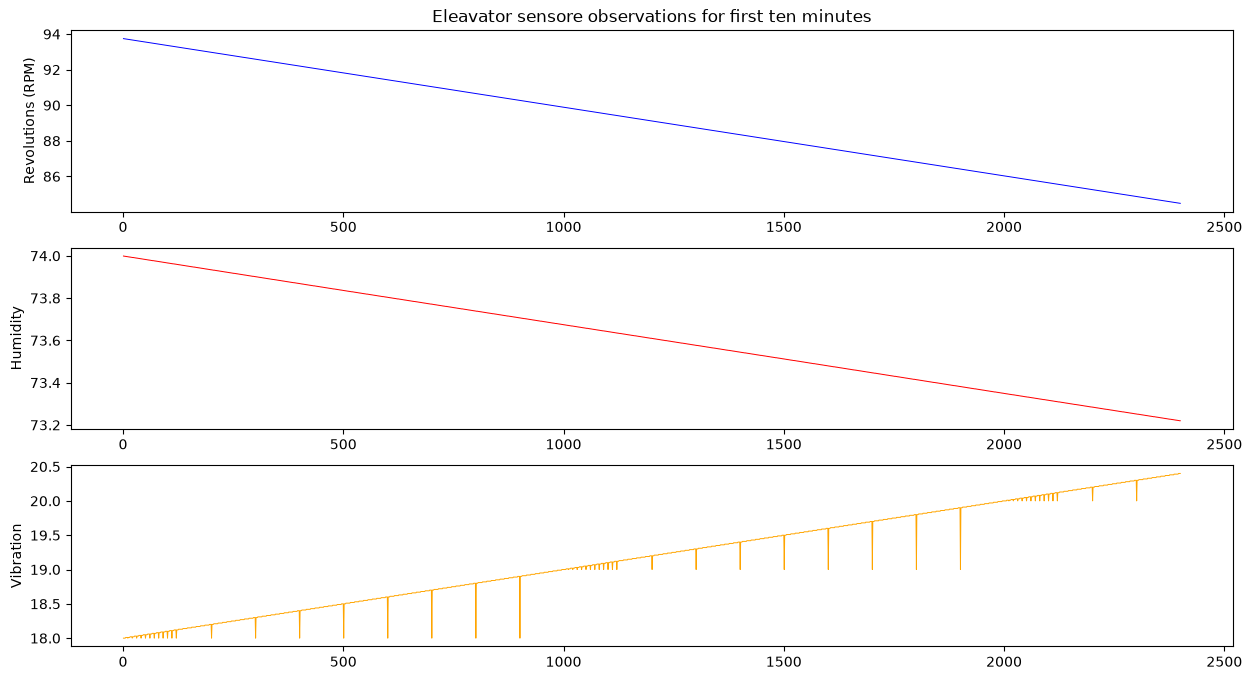

In [10]:
# Lets plot linear plot to see sensors data over time
ten_minutes_window = df.head(2400) # will visualize 10 minutes windo taken 24000 as 4 Hz = 0.25 sec for each record
fig,ax = plt.subplots(3,1,figsize=(15,8))
# Revolutions
ax[0].plot(ten_minutes_window['ID'],ten_minutes_window['revolutions'],color = 'blue',linewidth = 0.7)
ax[0].set_ylabel('Revolutions (RPM)')
ax[0].set_title('Eleavator sensore observations for first ten minutes')
# Humidity
ax[1].plot(ten_minutes_window['ID'],ten_minutes_window['humidity'],color = 'red',linewidth = 0.7)
ax[1].set_ylabel('Humidity')
# Vibration
ax[2].plot(ten_minutes_window['ID'], ten_minutes_window['vibration'],color = 'orange',linewidth = 0.7)
ax[2].set_ylabel('Vibration')
plt.show()


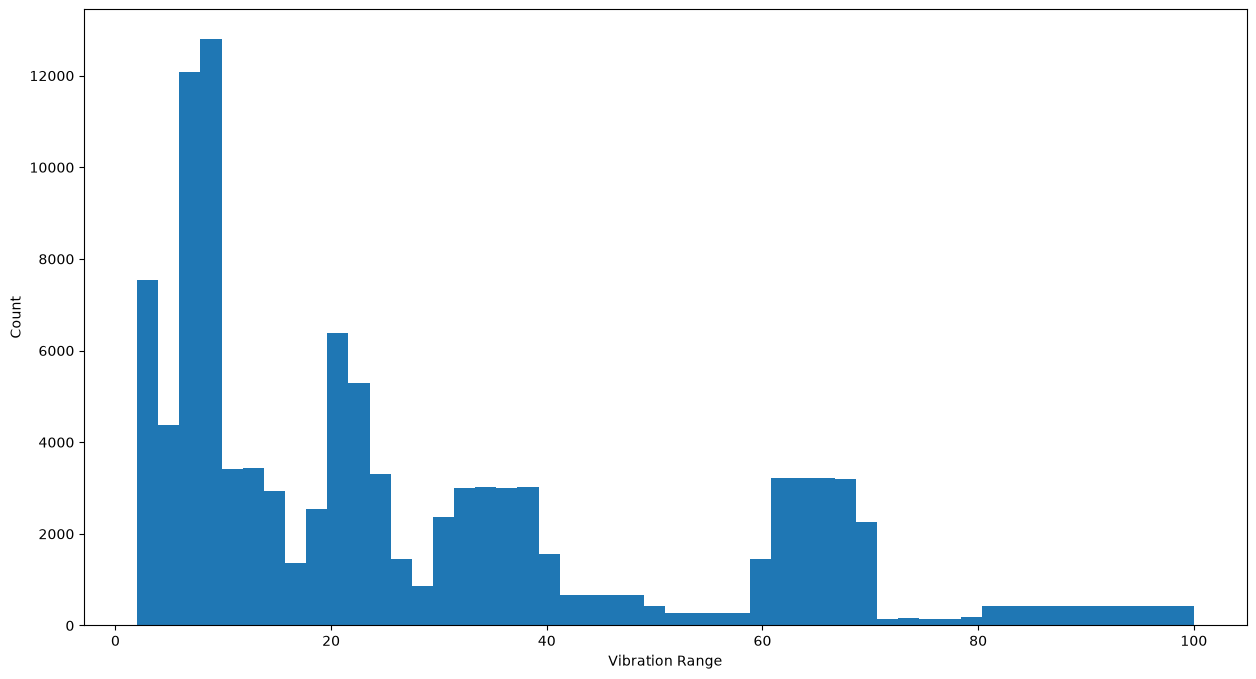

In [11]:
vibration_without_nan = df['vibration'].dropna()
plt.figure(figsize = (15,8))
plt.hist(vibration_without_nan, bins = 50)
plt.xlabel('Vibration Range')
plt.ylabel('Count')
plt.show()

### Observation
+ Most vibration values are low (5 - 40).
+ Vibration is right skewed 
+ we want to detect high vibration events

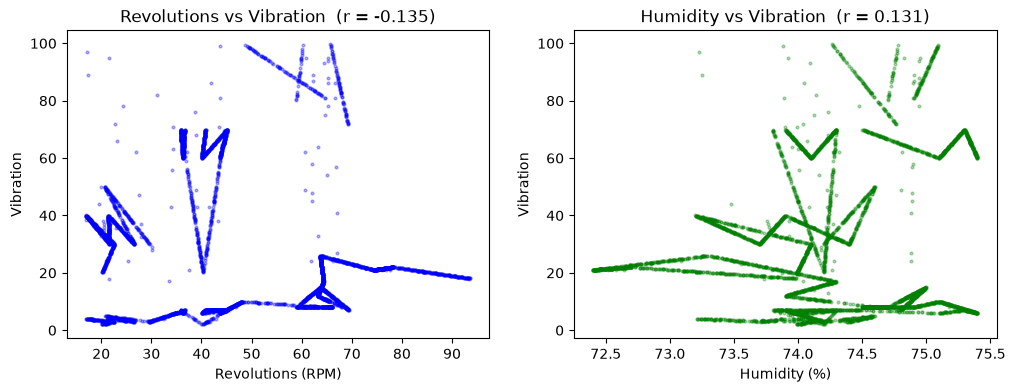

In [12]:
sample = df.dropna(subset=["vibration"]).sample(5000, random_state=42)
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
# Left: revolutions vs vibration
axes[0].scatter(sample["revolutions"], sample["vibration"],
                alpha=0.3, s=4, color="blue")
r_value = sample["revolutions"].corr(sample["vibration"])
axes[0].set_xlabel("Revolutions (RPM)")
axes[0].set_ylabel("Vibration")
axes[0].set_title(f"Revolutions vs Vibration  (r = {r_value:.3f})")
 
# Right: humidity vs vibration
axes[1].scatter(sample["humidity"], sample["vibration"],
                alpha=0.3, s=4, color="green")
r_hum = sample["humidity"].corr(sample["vibration"])
axes[1].set_xlabel("Humidity (%)")
axes[1].set_ylabel("Vibration")
axes[1].set_title(f"Humidity vs Vibration  (r = {r_hum:.3f})")
plt.show()

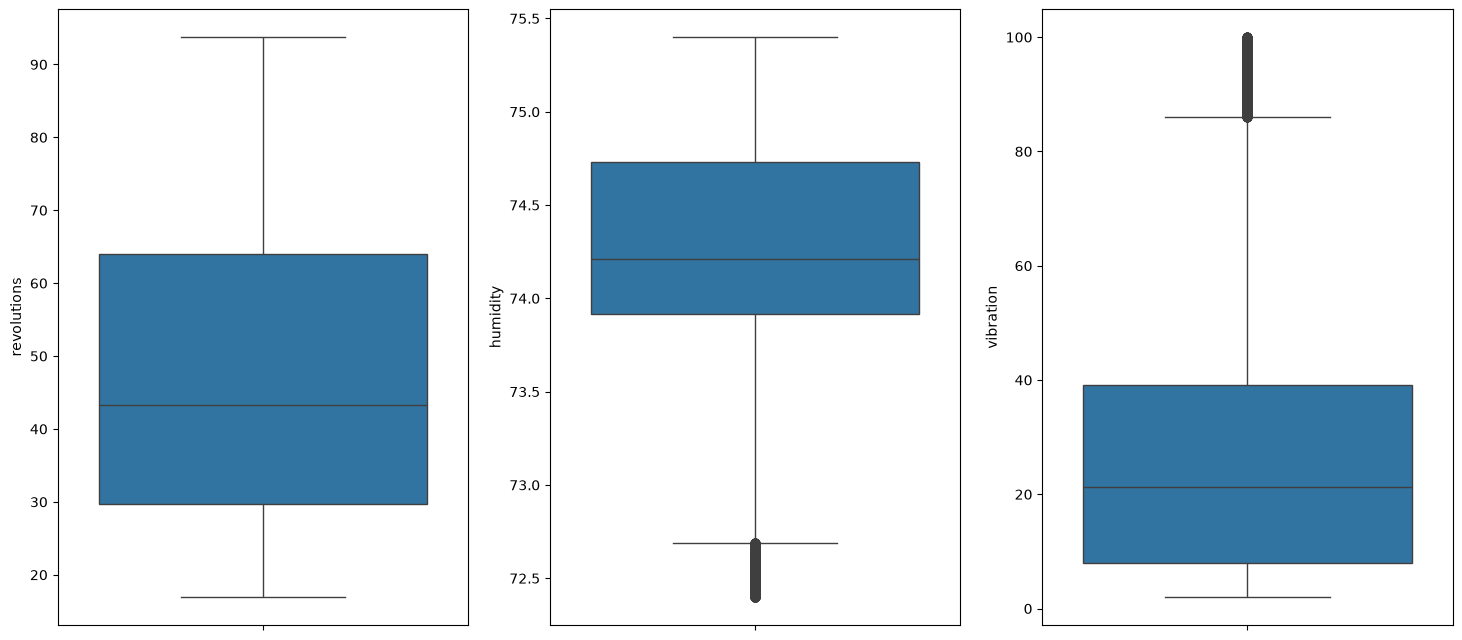

In [13]:
fig,ax =  plt.subplots(1,3,figsize = (18,8))
sns.boxplot(df['revolutions'],ax=ax[0])
sns.boxplot(df['humidity'],ax=ax[1])
sns.boxplot(df['vibration'],ax=ax[2])
plt.show()

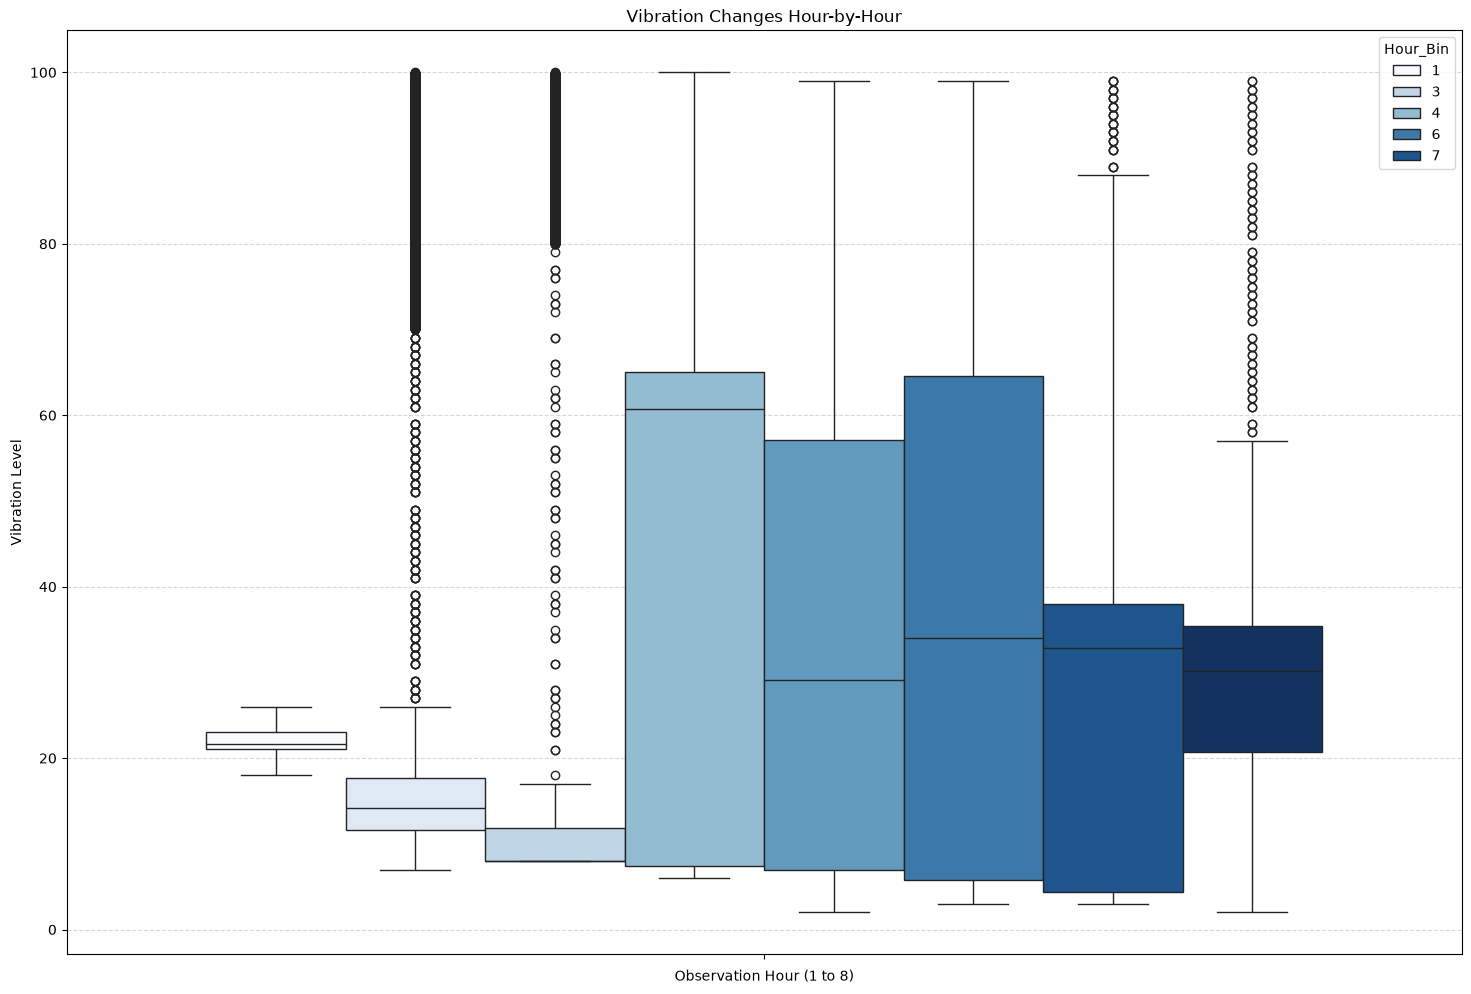

In [14]:
# 1. Create a helper column to group data into 8 distinct hours
# (Assuming your ID rows are sequential from 0 to the end of the 7.8 hours)
total_rows = len(df)
df["Hour_Bin"] = np.minimum(
    (df.reset_index().index / (total_rows / 7.8)).astype(int) + 1, 8
)

# Plot a boxplot for each hour chunk
plt.figure(figsize=(18, 12))
sns.boxplot(hue="Hour_Bin", y="vibration", data=df, palette="Blues")

plt.title("Vibration Changes Hour-by-Hour")
plt.xlabel("Observation Hour (1 to 8)")
plt.ylabel("Vibration Level")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

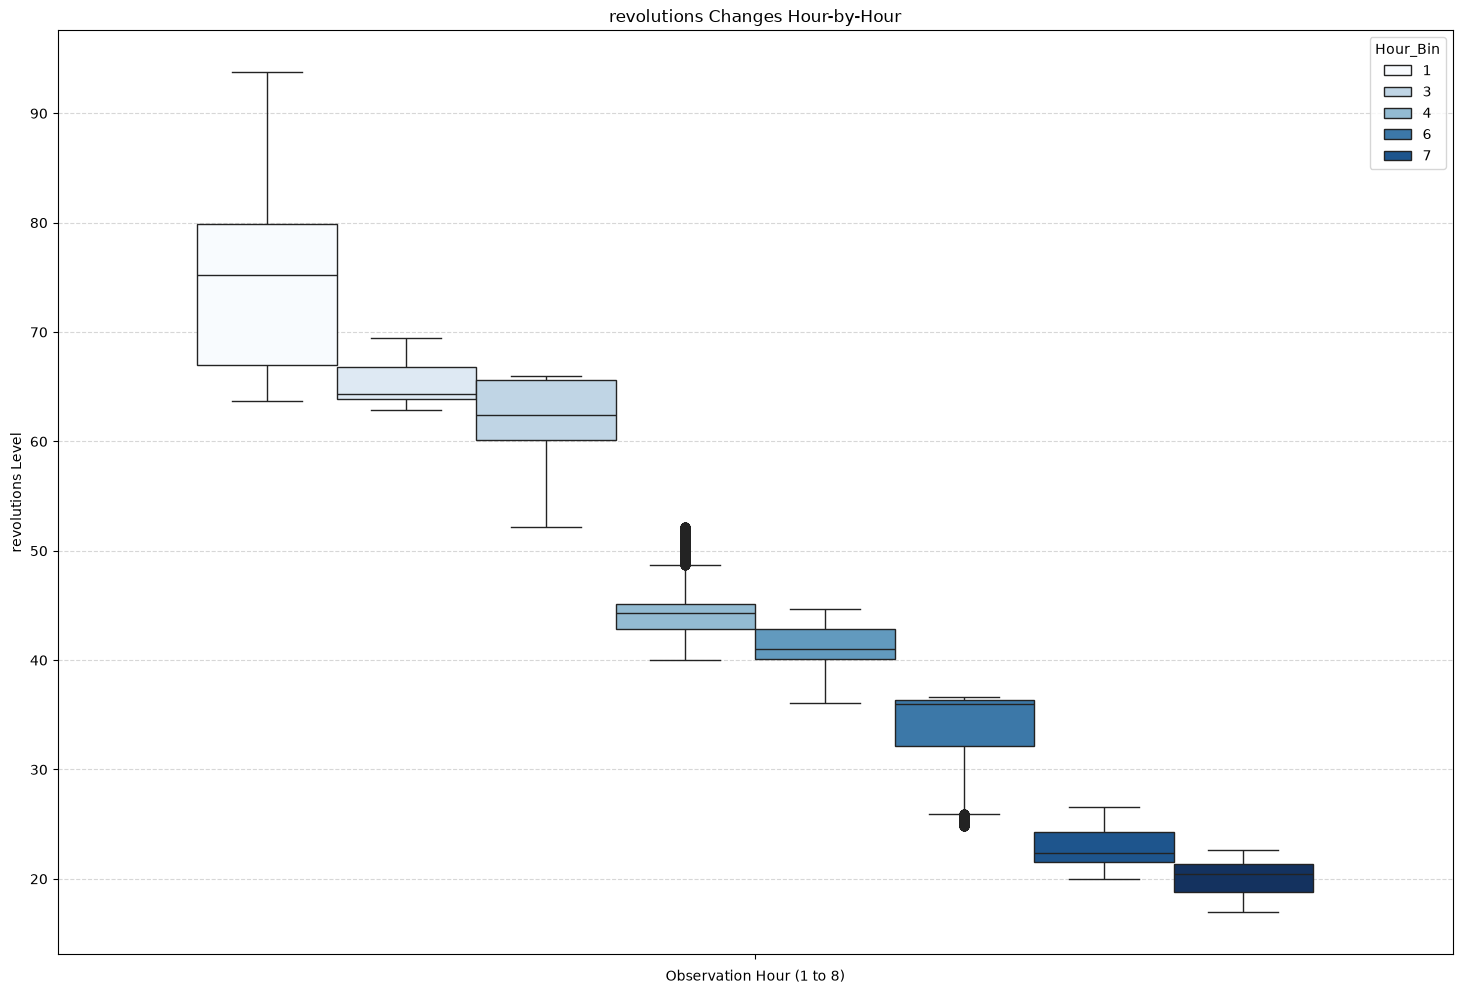

In [15]:
plt.figure(figsize=(18, 12))
sns.boxplot(hue="Hour_Bin", y="revolutions", data=df, palette="Blues")

plt.title("revolutions Changes Hour-by-Hour")
plt.xlabel("Observation Hour (1 to 8)")
plt.ylabel("revolutions Level")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

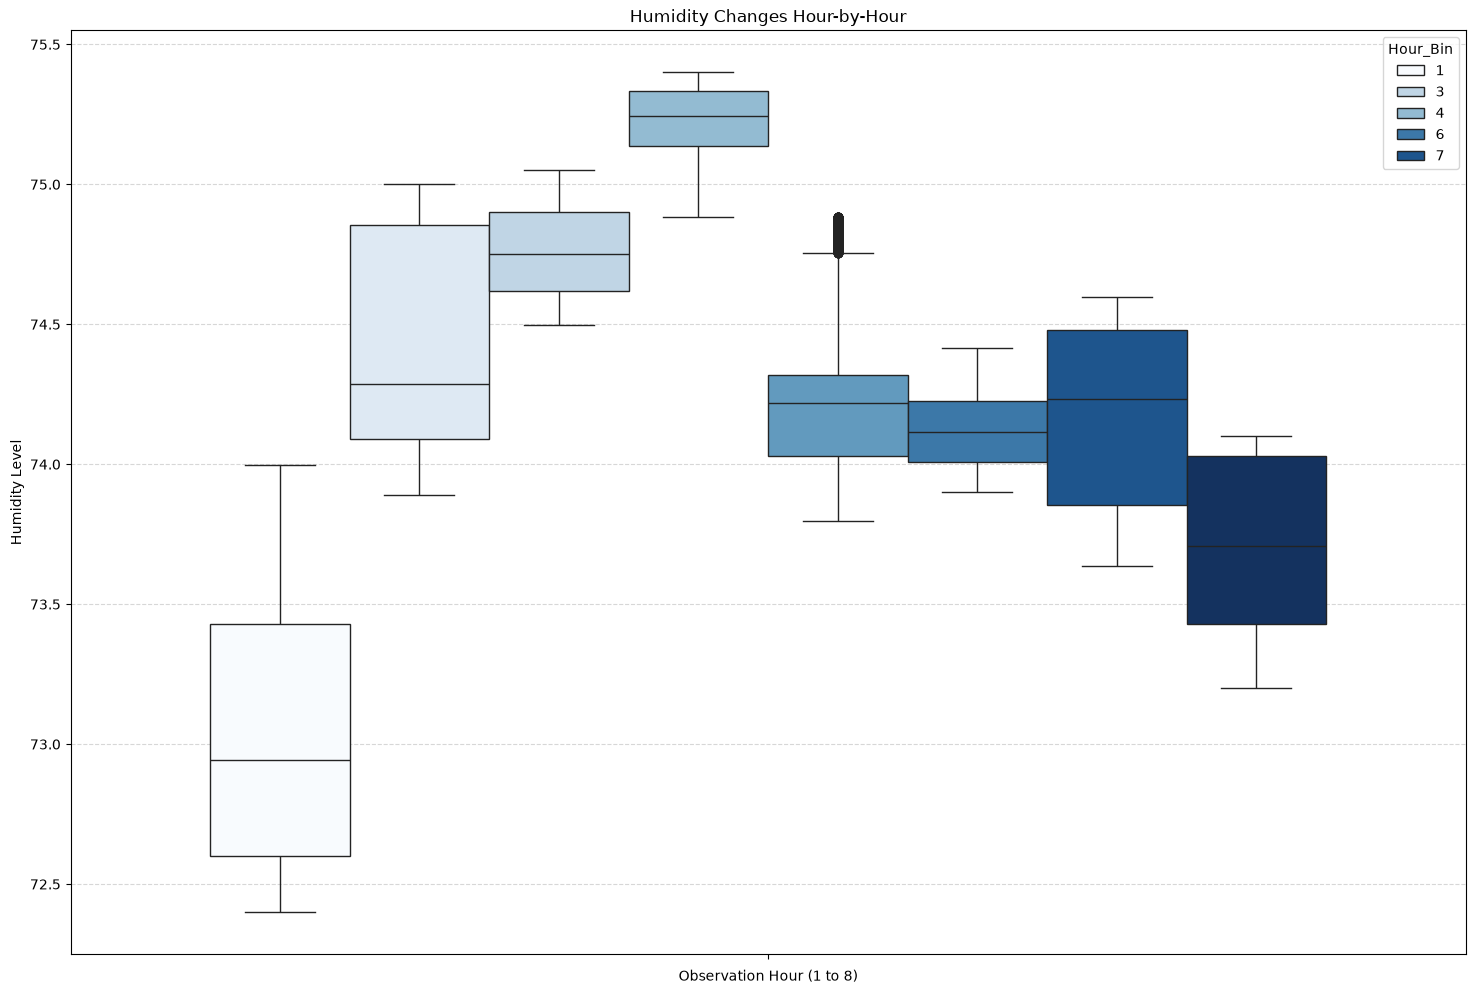

In [16]:
plt.figure(figsize=(18, 12))
sns.boxplot(hue="Hour_Bin", y="humidity", data=df, palette="Blues")

plt.title("Humidity Changes Hour-by-Hour")
plt.xlabel("Observation Hour (1 to 8)")
plt.ylabel("Humidity Level")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

+ 75% of total observations for Vibration are below 40
+ vibration does have outliers
+ humidity changes slighty over the period of observation

## Missing Values

In [17]:
total_rows = len(df)
total_missing = df['vibration'].isnull().sum()
missing_percentage = ( total_missing / total_rows ) * 100
print(f'Missing Percentage {missing_percentage:.2f}%')

Missing Percentage 2.18%


In [18]:
Nan_records = df.index[df['vibration'].isnull()].tolist()

In [19]:
Nan_records # we take index list of missing records

[20008,
 20016,
 20024,
 20032,
 20040,
 20048,
 20056,
 20064,
 20072,
 20088,
 20096,
 20104,
 20112,
 20120,
 20128,
 20136,
 20144,
 20152,
 20168,
 20176,
 20184,
 20192,
 20200,
 20208,
 20216,
 20224,
 20232,
 20248,
 20256,
 20264,
 20272,
 20280,
 20288,
 20296,
 20304,
 20312,
 20328,
 20336,
 20344,
 20352,
 20360,
 20368,
 20376,
 20384,
 20392,
 20408,
 20416,
 20424,
 20432,
 20440,
 20448,
 20456,
 20464,
 20472,
 20488,
 20496,
 20504,
 20512,
 20520,
 20528,
 20536,
 20544,
 20552,
 20568,
 20576,
 20584,
 20592,
 20600,
 20608,
 20616,
 20624,
 20632,
 20648,
 20656,
 20664,
 20672,
 20680,
 20688,
 20696,
 21608,
 21616,
 21624,
 21632,
 21640,
 21648,
 21656,
 21664,
 21672,
 21688,
 21696,
 21704,
 21712,
 21720,
 21728,
 21736,
 21744,
 21752,
 21768,
 21776,
 21784,
 21792,
 21800,
 21808,
 21816,
 21824,
 21832,
 21848,
 21856,
 21864,
 21872,
 21880,
 21888,
 21896,
 21904,
 21912,
 21928,
 21936,
 21944,
 21952,
 21960,
 21968,
 21976,
 21984,
 21992,
 22008,


In [20]:
gaps = []
for i in range(len(Nan_records) - 1):
    gap = Nan_records[i+1] - Nan_records[i]
    gaps.append(gap)
 
# Find the most common gap
most_common_gap = max(set(gaps), key=gaps.count)


In [21]:
print(f"\n  Gap between missing values: {most_common_gap} rows")
print(f"  In seconds: {most_common_gap} × 0.25 = {most_common_gap * 0.25} seconds")



  Gap between missing values: 8 rows
  In seconds: 8 × 0.25 = 2.0 seconds


#### CONCLUSION: 
One vibration reading drops every 2 seconds
This is a REGULAR PATTERN - the sensor firmware pauses
briefly to flush its write buffer. This is called MNAR
(Missing Not At Random - it follows a fixed schedule).

### Visualise the missing pattern

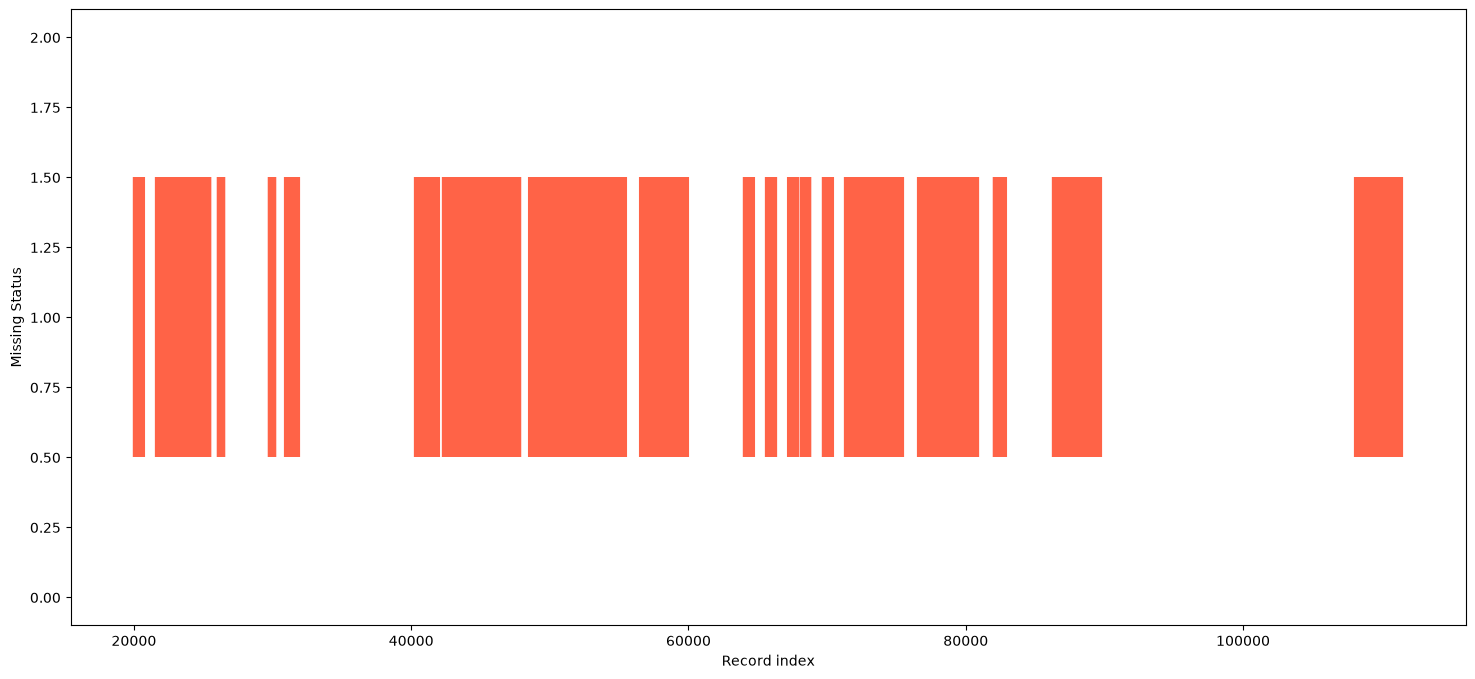

In [22]:
# we will plot eventplot to visualise missing values in vibration 
plt.figure(figsize = (18,8))
plt.eventplot([Nan_records],orientation = 'horizontal',colors = ['tomato'])
plt.xlabel('Record index')
plt.ylabel('Missing Status')
plt.show()
 

#### We will fill missing values using ffill it wll add the last know value of vibration for current missing value

In [23]:
df['vibration'] = df['vibration'].ffill()
df['vibration'] = df['vibration'].bfill() # if we having missing value at first record then it will handle that scenario

In [24]:
df.isnull().sum() # so we have filled our missing values using ffill

ID             0
revolutions    0
humidity       0
vibration      0
x1             0
x2             0
x3             0
x4             0
x5             0
Hour_Bin       0
dtype: int64

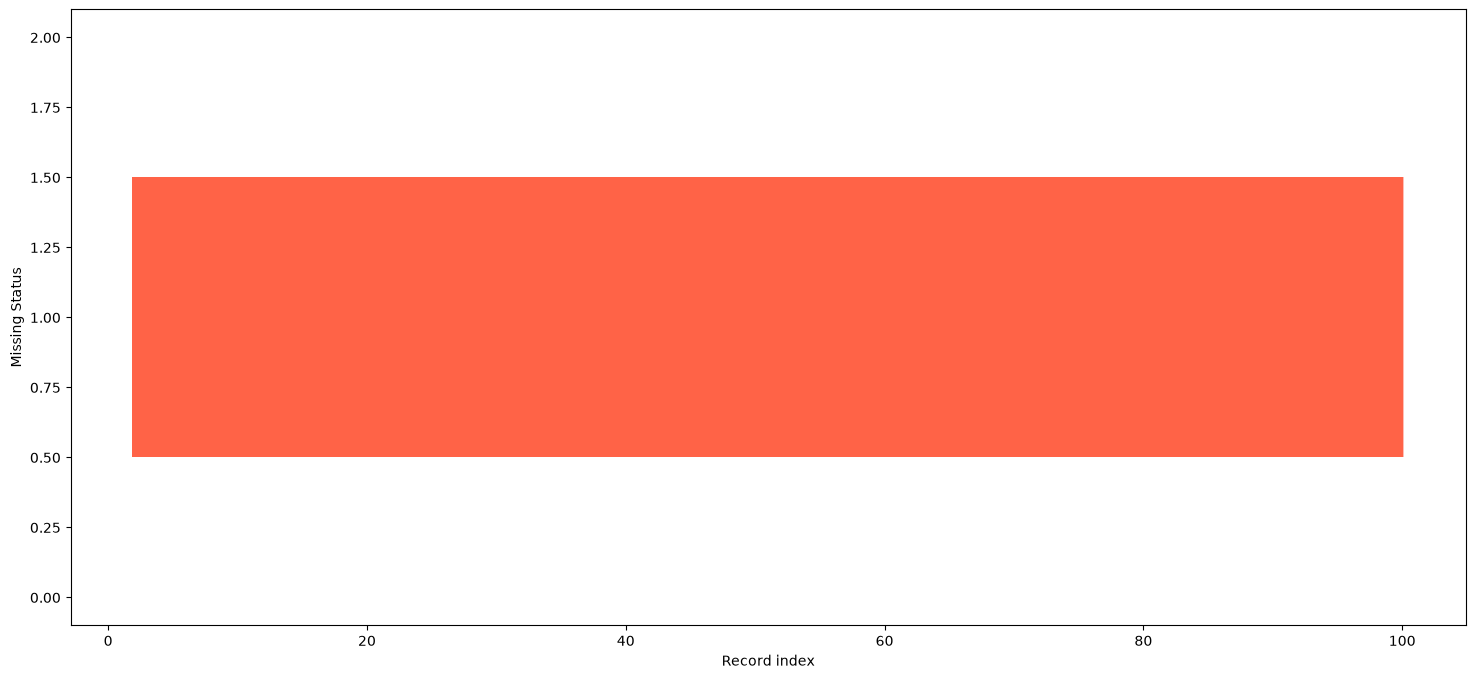

In [25]:
# we will plot eventplot to visualise missing values in vibration 
plt.figure(figsize = (18,8))
plt.eventplot(df['vibration'],orientation = 'horizontal',colors = ['tomato'])
plt.xlabel('Record index')
plt.ylabel('Missing Status')
plt.show()
 

### Observations
+ we observed MNAR (Missing Not At
  Random) pattern. so as we are having time series problem statement to avoid data leakage 
  We applied Last Observation Carried Forward (LOCF)
  imputation, which is appropriate because the gap duration
  (0.25 seconds) is negligible relative to the signal's rate of
  change. All missing values were successfully imputed

#### Exploring other features (x1,x2,x3,x4,x5) and their relation with Target Feature

In [26]:
df.head()

,ID,revolutions,humidity,vibration,x1,x2,x3,x4,x5,Hour_Bin
0,1,93.744,73.999,18.0,167.743,19.745,1.266828,8787.937536,5475.852001,1
1,2,93.740,73.999,18.0,167.739,19.741,1.266774,8787.187600,5475.852001,1
2,3,93.736,73.998,18.0,167.734,19.738,1.266737,8786.437696,5475.704004,1
3,4,93.732,73.998,18.0,167.730,19.734,1.266683,8785.687824,5475.704004,1
4,5,93.729,73.998,18.0,167.727,19.731,1.266642,8785.125441,5475.704004,1


In [27]:
df.corr()

,ID,revolutions,humidity,vibration,x1,x2,x3,x4,x5,Hour_Bin
ID,1.000000,-0.973084,0.061616,0.081942,-0.973796,-0.971137,-0.972381,-0.938444,0.058631,0.991989
revolutions,-0.973084,1.000000,-0.101476,-0.110156,0.999356,0.999365,0.999593,0.982563,-0.098903,-0.968008
humidity,0.061616,-0.101476,1.000000,0.137420,-0.065716,-0.136847,-0.128683,-0.207702,0.999980,0.055638
vibration,0.081942,-0.110156,0.137420,1.000000,-0.105532,-0.114606,-0.112859,-0.138425,0.137741,0.078530
x1,-0.973796,0.999356,-0.065716,-0.105532,1.000000,0.997444,0.997967,0.978035,-0.063136,-0.968921
x2,-0.971137,0.999365,-0.136847,-0.114606,0.997444,1.000000,0.999934,0.985806,-0.134285,-0.965868
x3,-0.972381,0.999593,-0.128683,-0.112859,0.997967,0.999934,1.000000,0.985077,-0.126093,-0.967092
x4,-0.938444,0.982563,-0.207702,-0.138425,0.978035,0.985806,0.985077,1.000000,-0.205227,-0.929680
x5,0.058631,-0.098903,0.999980,0.137741,-0.063136,-0.134285,-0.126093,-0.205227,1.000000,0.052638
Hour_Bin,0.991989,-0.968008,0.055638,0.078530,-0.968921,-0.965868,-0.967092,-0.929680,0.052638,1.000000


### Will find formula for each reading

In [28]:
# Check x1
diff = df["x1"] - (df["revolutions"] + df["humidity"])
if diff.std() < 0.0001:
    print("x1 = revolutions + humidity")
else:
    print("x1 = revolutions + humidity ")

# Check x2
diff = df["x2"] - (df["revolutions"] - df["humidity"])
if diff.std() < 0.0001:
    print("x2 = revolutions - humidity")
else:
    print("x2 = revolutions - humidity ")

# Check x3
diff = df["x3"] - (df["revolutions"] / df["humidity"])
if diff.std() < 0.0001:
    print("x3 = revolutions / humidity")
else:
    print("x3 = revolutions / humidity ")

# Check x4
diff = df["x4"] - (df["revolutions"] ** 2)
if diff.std() < 0.0001:
    print("x4 = revolutions²")
else:
    print("x4 = revolutions² ")

# Check x5
diff = df["x5"] - (df["humidity"] ** 2)
if diff.std() < 0.0001:
    print("x5 = humidity²")
else:
    print("x5 = humidity² ")

x1 = revolutions + humidity
x2 = revolutions - humidity
x3 = revolutions / humidity
x4 = revolutions²
x5 = humidity²


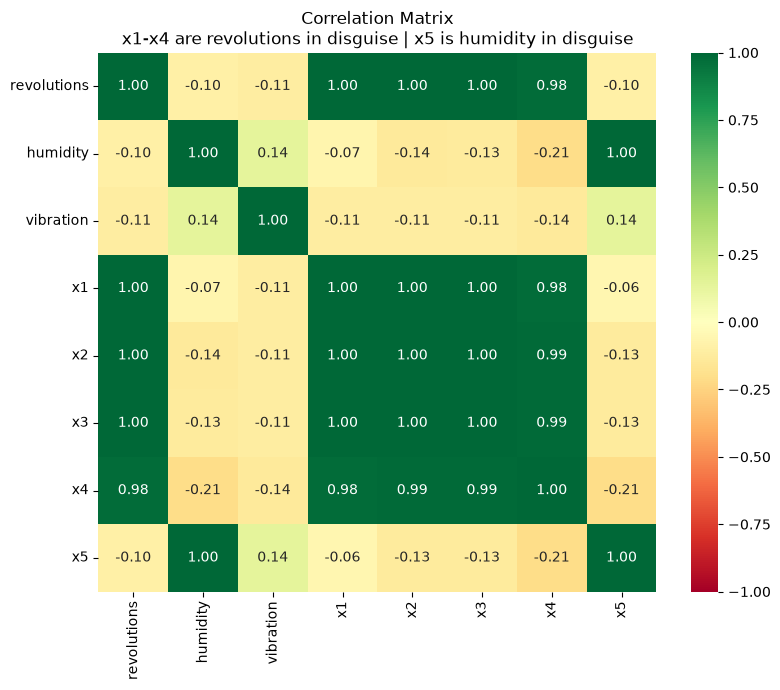

In [29]:
columns_to_check = ["revolutions", "humidity", "vibration",
                    "x1", "x2", "x3", "x4", "x5"]
corr_matrix      = df[columns_to_check].corr().round(2) 
 
plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,          # show numbers inside squares
    fmt=".2f",           # 2 decimal places
    cmap="RdYlGn",       # red=negative, yellow=zero, green=positive
    center=0,
    vmin=-1, vmax=1
)
plt.title("Correlation Matrix\n"
          "x1-x4 are revolutions in disguise | x5 is humidity in disguise")
plt.show()

### Observation 
+ Reading : x1, x2, x3, x4 are almost perfectly correlated with revolutions
+ x5 is almost perfectly correlated with humidity


### Conclusion
+ x1 = revolutions + humidity
+ x2 = revolutions - humidity
+ x3 = revolutions / humidity
+ x4 = revolutions²
+ x5 = humidity²      
Correlation analysis and exact residual tests reveal that the
  five auxiliary features (x1–x5) are polynomial transformations
  of two root variables:
    x1 = rev + hum,  x2 = rev - hum,  x3 = rev / hum,
    x4 = rev²,       x5 = hum²

In [30]:
df.to_csv('../data/processed/elevator_clean.csv')